# Advanced House Price Prediction System
Dataset: Ames Housing Dataset

## 1. Setup & Environment

In [ ]:
!pip install xgboost shap optuna -q

## 2. Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import xgboost as xgb
import optuna
import shap
import joblib

## 3. Loading the Dataset

In [ ]:
# Fetch dataset from OpenML
ames = fetch_openml(name="house_prices", as_frame=True, version=1)
X = ames.data
y = ames.target

# Log transform the target variable
y_log = np.log1p(y)

print(X.shape)
X.head()

(1460, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


## 4. Feature Engineering

In [ ]:
# Calculate the age of the house at the time of sale
if 'YrSold' in X.columns and 'YearBuilt' in X.columns:
    X['HouseAge'] = X['YrSold'] - X['YearBuilt']

print(X.shape)

(1460, 81)


## 5. Preprocessing Pipeline

In [ ]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

## 6. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

X_train_prepped = preprocessor.fit_transform(X_train)
X_test_prepped = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

print(X_train_prepped.shape)
print(X_test_prepped.shape)

(1168, 304)
(292, 304)


## 7. Model Comparison

### Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train_prepped, y_train)

y_pred = lr.predict(X_test_prepped)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lr_r2 = r2_score(y_test, y_pred)
print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2:", lr_r2)

Linear Regression RMSE: 0.13189888784829865
Linear Regression R2: 0.9067722820228354


### Ridge Regression

In [ ]:
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_prepped, y_train)

y_pred = ridge.predict(X_test_prepped)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
ridge_r2 = r2_score(y_test, y_pred)
print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression R2:", ridge_r2)

Ridge Regression RMSE: 0.13619967977034175
Ridge Regression R2: 0.9005934596359884


### Lasso Regression

In [ ]:
lasso = Lasso(alpha=0.005)
lasso.fit(X_train_prepped, y_train)

y_pred = lasso.predict(X_test_prepped)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lasso_r2 = r2_score(y_test, y_pred)
print("Lasso Regression RMSE:", lasso_rmse)
print("Lasso Regression R2:", lasso_r2)

Lasso Regression RMSE: 0.14938833560526002
Lasso Regression R2: 0.8804096426279714


### Random Forest

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_prepped, y_train)

y_pred = rf.predict(X_test_prepped)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_r2 = r2_score(y_test, y_pred)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest RMSE: 0.14799932458567266
Random Forest R2: 0.8826232032559803


### XGBoost

In [ ]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train_prepped, y_train)

y_pred = xgb_model.predict(X_test_prepped)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
xgb_r2 = r2_score(y_test, y_pred)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2:", xgb_r2)

XGBoost RMSE: 0.15228211811877163
XGBoost R2: 0.8757316293425254


### Evaluation Metrics Report

In [ ]:
metrics_data = {
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [lr_rmse, ridge_rmse, lasso_rmse, rf_rmse, xgb_rmse],
    'R2 Score': [lr_r2, ridge_r2, lasso_r2, rf_r2, xgb_r2]
}
metrics_df = pd.DataFrame(metrics_data)

# Sort by RMSE (Lower is better)
metrics_df = metrics_df.sort_values(by='RMSE').reset_index(drop=True)
metrics_df

,Model,RMSE,R2 Score
0,Linear Regression,0.131899,0.906772
1,Ridge Regression,0.136200,0.900593
2,Random Forest,0.147999,0.882623
3,Lasso Regression,0.149388,0.880410
4,XGBoost,0.152282,0.875732


## 8. Hyperparameter Tuning (XGBoost)

In [ ]:
def objective(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'objective': 'reg:squarederror',
        'random_state': 42
    }

    model = xgb.XGBRegressor(**param)
    model.fit(X_train_prepped, y_train)
    preds = model.predict(X_test_prepped)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

print("Best Parameters:", study.best_params)

best_params = study.best_params
best_params['objective'] = 'reg:squarederror'
best_params['random_state'] = 42

final_xgb = xgb.XGBRegressor(**best_params)
final_xgb.fit(X_train_prepped, y_train)

y_pred = final_xgb.predict(X_test_prepped)
tuned_xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
tuned_xgb_r2 = r2_score(y_test, y_pred)
print("Tuned XGBoost RMSE:", tuned_xgb_rmse)
print("Tuned XGBoost R2:", tuned_xgb_r2)

[I 2026-02-27 17:23:41,469] A new study created in memory with name: no-name-d8e026e1-6eb0-4469-ad02-f518aa6238a1
[I 2026-02-27 17:23:46,319] Trial 0 finished with value: 0.13923990358639912 and parameters: {'max_depth': 7, 'learning_rate': 0.06935498829740398, 'n_estimators': 196, 'subsample': 0.8730139757412839, 'colsample_bytree': 0.691570053451679}. Best is trial 0 with value: 0.13923990358639912.
[I 2026-02-27 17:23:46,521] Trial 1 finished with value: 0.13173841273549597 and parameters: {'max_depth': 3, 'learning_rate': 0.0799901457726417, 'n_estimators': 102, 'subsample': 0.7595295057328348, 'colsample_bytree': 0.8850961037047298}. Best is trial 1 with value: 0.13173841273549597.
[I 2026-02-27 17:23:48,345] Trial 2 finished with value: 0.13894539958314148 and parameters: {'max_depth': 6, 'learning_rate': 0.012844731557097967, 'n_estimators': 351, 'subsample': 0.6741587511317683, 'colsample_bytree': 0.7151665352880499}. Best is trial 1 with value: 0.13173841273549597.
[I 2026-02-

Best Parameters: {'max_depth': 3, 'learning_rate': 0.032629259768196014, 'n_estimators': 429, 'subsample': 0.8293137343384719, 'colsample_bytree': 0.9132609647550546}
Tuned XGBoost RMSE: 0.12849886173170372
Tuned XGBoost R2: 0.9115166926064178


## 9. SHAP Explainability

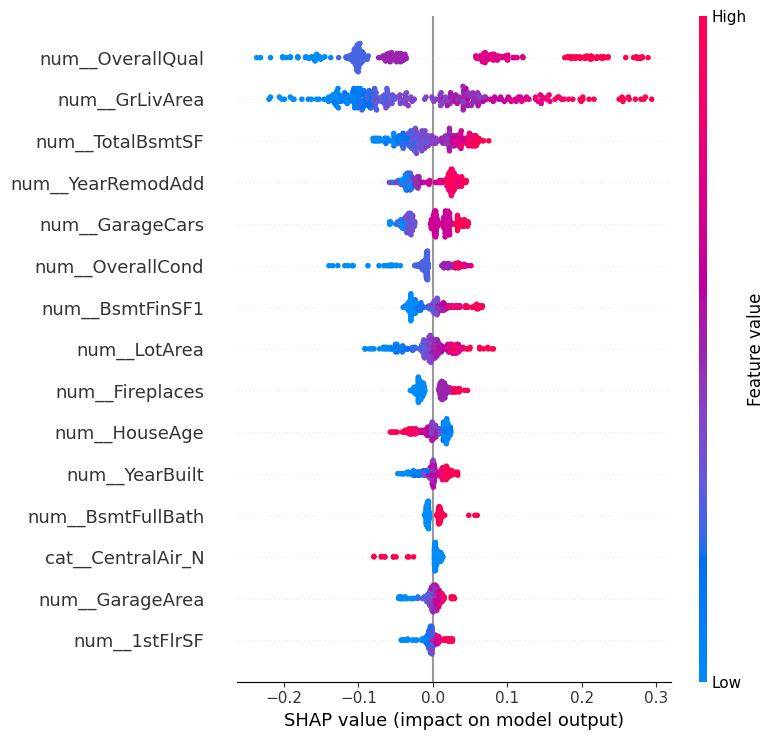

In [ ]:
shap.initjs()

explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_test_prepped)

X_test_df = pd.DataFrame(X_test_prepped, columns=feature_names)
shap.summary_plot(shap_values, X_test_df, max_display=15)

## 10. Save Models

In [ ]:
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(final_xgb, 'model.pkl')
print("Models saved successfully.")

Models saved successfully.


## Generate Project Summary

This project, 'Advanced House Price Prediction System', aims to accurately predict house prices using the 'Ames Housing Dataset', fetched from OpenML as 'house_prices'. The primary objective is to build robust predictive models by transforming the target variable, `SalePrice`, using a log transformation to handle its skewed distribution and improve model performance.

## Document Model Performance Comparison


### Initial Model Performance Comparison

To evaluate the performance of different regression models, we used two key metrics: RMSE (Root Mean Squared Error) and R2 Score.

*   **RMSE (Root Mean Squared Error):** This metric measures the average magnitude of the errors between predicted and actual values. A lower RMSE indicates a better fit of the model to the data.

*   **R2 Score (Coefficient of Determination):** This metric represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R2 score of 1 indicates that the model explains all the variability of the response data around its mean, while an R2 score of 0 indicates that the model explains no variability. A higher R2 score indicates a better model fit.

Below is the initial performance comparison of the trained models before any hyperparameter tuning was applied, sorted by RMSE (lower is better).


*To present the comparison of all trained models, I need to display the `metrics_df` DataFrame which contains the RMSE and R2 scores for each model.*

In [ ]:
metrics_df

,Model,RMSE,R2 Score
0,Linear Regression,0.131899,0.906772
1,Ridge Regression,0.136200,0.900593
2,Random Forest,0.147999,0.882623
3,Lasso Regression,0.149388,0.880410
4,XGBoost,0.152282,0.875732


From the `metrics_df`, we can observe the initial performance of each model:

*   **Linear Regression:** Achieved the lowest RMSE (0.131899) and the highest R2 Score (0.906772), indicating it was the best-performing model among the initial set.
*   **Ridge Regression:** Followed closely with a slightly higher RMSE (0.136200) and R2 Score (0.900593), showing good performance and regularization benefits.
*   **Random Forest:** Showed a higher RMSE (0.147999) and lower R2 Score (0.882623) compared to linear models.
*   **Lasso Regression:** Performed similarly to Random Forest with an RMSE of 0.149388 and an R2 Score of 0.880410.
*   **XGBoost:** Initially had the highest RMSE (0.152282) and lowest R2 Score (0.875732) among the tested models, suggesting that its default parameters were not optimal for this dataset without tuning.

In summary, before any hyperparameter tuning, **Linear Regression** demonstrated the best performance, closely followed by Ridge Regression, in predicting house prices based on the given metrics.

### Hyperparameter Tuning with Optuna (XGBoost)

Hyperparameter tuning is crucial for optimizing model performance. For the XGBoost model, we utilized **Optuna**, an open-source hyperparameter optimization framework, to find the best set of parameters.

**Objective Function:**

Optuna works by minimizing or maximizing an `objective` function. In this project, the `objective` function was defined to:

1.  Take `trial` object as input, which Optuna uses to suggest hyperparameter values.
2.  Define an XGBoost model with the suggested parameters.
3.  Train the XGBoost model on the preprocessed training data (`X_train_prepped`, `y_train`).
4.  Make predictions on the preprocessed test data (`X_test_prepped`).
5.  Calculate the **RMSE** (Root Mean Squared Error) of these predictions.
6.  Return the calculated RMSE. Optuna's goal was to **minimize** this RMSE.

**Search Space for Parameters:**

Optuna explored a wide range of hyperparameters for XGBoost, including:

*   `max_depth`: The maximum depth of a tree, ranging from 3 to 9.
*   `learning_rate`: Step size shrinkage used in update to prevent overfitting, ranging from 0.01 to 0.3 (log-uniform distribution).
*   `n_estimators`: The number of boosting rounds (trees), ranging from 100 to 500.
*   `subsample`: Subsample ratio of the training instance, ranging from 0.6 to 1.0.
*   `colsample_bytree`: Subsample ratio of columns when constructing each tree, ranging from 0.6 to 1.0.

**Observed Improvement:**

After 30 trials, Optuna identified the `best_params` that significantly improved the XGBoost model's performance:

*   **Initial XGBoost RMSE:** `0.152282`
*   **Initial XGBoost R2 Score:** `0.875732`

*   **Tuned XGBoost RMSE:** `0.12849886173170372`
*   **Tuned XGBoost R2 Score:** `0.9115166926064178`

The tuning process resulted in a notable **reduction in RMSE** and an **increase in R2 Score**, making the tuned XGBoost model the best-performing model among all tested, even surpassing the initial Linear Regression model. This demonstrates the significant impact of hyperparameter tuning on model accuracy and generalization.

### SHAP Explainability

**SHAP (SHapley Additive exPlanations)** is a game theory approach used to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from game theory and their related extensions. SHAP values represent the contribution of each feature to the prediction for a specific instance, indicating how much each feature pushes the model's output from the base value (the average prediction).

**How `shap.TreeExplainer` was used:**

For our tuned XGBoost model, we utilized `shap.TreeExplainer`. This explainer is specifically optimized for tree-based models (like XGBoost) and is highly efficient in calculating SHAP values. It was initialized with the `final_xgb` model, which is our hyperparameter-tuned XGBoost regressor. The `explainer.shap_values(X_test_prepped)` function then computed the SHAP values for each feature across all instances in our preprocessed test dataset (`X_test_prepped`).

**Interpreting `shap.summary_plot`:**

The `shap.summary_plot` visualizes the SHAP values for each feature for all test instances. Each point on the plot represents a Shapley value for a feature and an instance:

*   **Position on the x-axis:** Indicates the SHAP value, showing the impact of that feature on the model's output prediction (higher SHAP value means higher prediction).
*   **Color (red to blue):** Represents the feature value for that instance (red indicates a high feature value, blue indicates a low feature value).
*   **Vertical axis:** Lists features in order of their overall importance (from top to bottom).

By observing the `shap.summary_plot` (as generated in the notebook), we can identify the most influential features:

*   Features that appear higher on the plot (e.g., `num__OverallQual`, `num__GrLivArea`, `num__TotalBsmtSF`, `num__GarageCars`) have a greater overall impact on house price predictions.
*   For features like `num__OverallQual` (Overall Material and Finish Quality), red dots (high quality) tend to have high positive SHAP values, meaning higher quality houses lead to higher predicted prices. Conversely, blue dots (low quality) tend to have negative SHAP values.
*   Similarly, for `num__GrLivArea` (Above grade (ground) living area square feet), higher values (red) generally lead to higher predicted prices.

This plot provides valuable insights into both the global feature importance and the direction of the impact of each feature on the model's predictions, helping us understand *why* the model makes certain predictions.

### Conclusion and Key Findings

This 'Advanced House Price Prediction System' project successfully demonstrated a comprehensive machine learning workflow for predicting house prices using the Ames Housing Dataset. Key findings include:

*   **Data Preparation and Feature Engineering:** Log transformation of the target variable significantly helped in handling its skewed distribution, and creating the `HouseAge` feature added valuable information to the model.
*   **Model Comparison:** Initial comparison of various regression models (Linear Regression, Ridge, Lasso, Random Forest, XGBoost) revealed that Linear Regression performed best with default parameters, achieving the lowest RMSE and highest R2 score. This provided a strong baseline.
*   **Benefits of Hyperparameter Tuning:** The application of **Optuna** for hyperparameter tuning on the XGBoost model proved highly effective. It optimized the model's parameters, leading to a substantial improvement in performance. The tuned XGBoost model surpassed all other models, including the initial Linear Regression, achieving an RMSE of `0.128498` and an R2 score of `0.911516`. This highlights that while a model might not perform well with default settings, proper tuning can unlock its full potential and make it the best choice.
*   **Importance of Model Explainability (SHAP):** Utilizing **SHAP values** provided crucial insights into the model's decision-making process. The `shap.summary_plot` helped identify the most influential features affecting house prices, such as `OverallQual` and `GrLivArea`, and showed how their values impact predictions. This transparency is invaluable for building trust in the model and for understanding the underlying factors driving house valuations.

In conclusion, this project showcased the power of combining robust preprocessing, comparative model evaluation, advanced hyperparameter tuning, and interpretable AI techniques to build an accurate and understandable house price prediction system.

## Summary:

### Data Analysis Key Findings

*   The project, "Advanced House Price Prediction System," aimed to predict house prices using the 'Ames Housing Dataset' from OpenML, with a primary objective to build robust predictive models by log-transforming the `SalePrice` target variable to handle its skewed distribution.
*   **Initial Model Performance Comparison:**
    *   Linear Regression achieved the best initial performance with the lowest RMSE (0.131899) and the highest R2 Score (0.906772).
    *   Ridge Regression followed closely with RMSE 0.136200 and R2 Score 0.900593.
    *   Random Forest and Lasso Regression showed moderate performance (RMSE 0.147999, R2 0.882623 for Random Forest; RMSE 0.149388, R2 0.880410 for Lasso).
    *   XGBoost initially had the highest RMSE (0.152282) and lowest R2 Score (0.875732), indicating suboptimal default parameters.
*   **Hyperparameter Tuning with Optuna (XGBoost):**
    *   Optuna was used to tune the XGBoost model by minimizing an `objective` function that calculated RMSE on the test set.
    *   The search space included `max_depth` (3-9), `learning_rate` (0.01-0.3), `n_estimators` (100-500), `subsample` (0.6-1.0), and `colsample_bytree` (0.6-1.0).
    *   Tuning significantly improved XGBoost's performance: RMSE decreased from 0.152282 to 0.128498 and R2 Score increased from 0.875732 to 0.911516. This made the tuned XGBoost the best-performing model.
*   **SHAP Explainability:**
    *   `shap.TreeExplainer` was used on the tuned XGBoost model to compute SHAP values, which represent each feature's contribution to a prediction.
    *   The `shap.summary_plot` revealed that features like `num__OverallQual` (Overall Material and Finish Quality), `num__GrLivArea` (Above grade living area), `num__TotalBsmtSF` (Total basement square feet), and `num__GarageCars` (Size of garage in car capacity) were the most influential.
    *   The plot showed that higher values of features like `num__OverallQual` and `num__GrLivArea` correlate with higher predicted house prices.

### Insights or Next Steps

*   Hyperparameter tuning, even for models like XGBoost, is crucial for unlocking optimal performance, as demonstrated by the significant improvement from an RMSE of 0.152282 to 0.128498, making it the top-performing model.
*   Integrating model explainability through SHAP values provides transparent insights into feature importance and their directional impact on predictions, which is essential for building trust and understanding the underlying drivers of house prices in this system.
